In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import timeit
import warnings
import random
import sys
sys.path.append("..") # go to parent folder
import src.infomap_funcs as inf

In [2]:
g_test = inf.generate_sbm(n=200, c=10, p_in=0.25, p_out=0.02, directed=False, weighted=True)
communities, L, p_mod, exit_data = inf.node_movement_optimization(g_test, returnTerms=True, verbose=True)

Starting from description length: 9.544758712000194
Current best description length: 7.717813405834054
Number of nodes that have been moved this iteration: 139
Continuing optimization.
Current best description length: 7.4323467657086795
Number of nodes that have been moved this iteration: 31
Continuing optimization.
Current best description length: 7.3546958277987216
Number of nodes that have been moved this iteration: 13
Continuing optimization.
Current best description length: 7.292732989144488
Number of nodes that have been moved this iteration: 10
Continuing optimization.
Current best description length: 7.282059418209282
Number of nodes that have been moved this iteration: 1
Continuing optimization.
Current best description length: 7.277774641804771
Number of nodes that have been moved this iteration: 1
Continuing optimization.
Current best description length: 7.277774641804771
Number of nodes that have been moved this iteration: 0
Optimization finished!
Final number of communitie

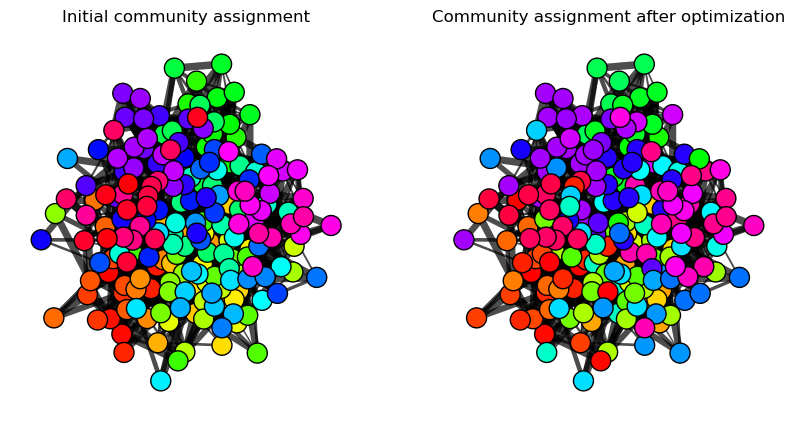

In [3]:
layout = g_test.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=np.arange(g_test.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=communities, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

In [4]:
g_test_directed = inf.generate_sbm(n=100, c=4, p_in=0.25, p_out=0.01, directed=True, weighted=True)
communities_directed, L, p_mod, exit_data = inf.node_movement_optimization(g_test_directed, returnTerms=True, verbose=True)

Starting from description length: 8.531936821509372
Current best description length: 6.971670692554588
Number of nodes that have been moved this iteration: 82
Continuing optimization.
Current best description length: 6.476410498787672
Number of nodes that have been moved this iteration: 34
Continuing optimization.
Current best description length: 6.182799085572667
Number of nodes that have been moved this iteration: 19
Continuing optimization.
Current best description length: 6.1497473074940014
Number of nodes that have been moved this iteration: 6
Continuing optimization.
Current best description length: 6.1497473074940014
Number of nodes that have been moved this iteration: 0
Optimization finished!
Final number of communities: 12
Final description length: 6.1497473074940014


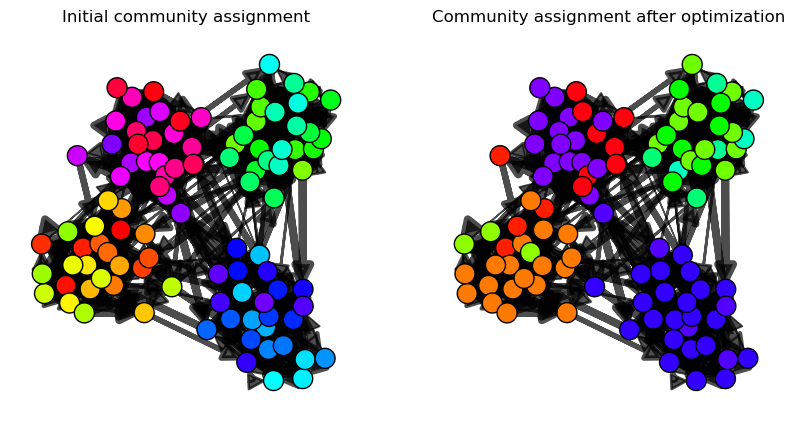

In [5]:
layout_directed = g_test_directed.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=np.arange(g_test_directed.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout_directed, **inf.visual_community_colors(g_test_directed, communities=communities_directed, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Community assignment after optimization")
plt.show()

In [6]:
def core_search_algorithm(g:ig.Graph, verbose=False):

    N = g.vcount() # number of nodes in graph
    flat_comms = np.arange(N, dtype=int) # we'll use this to track how each node in the og graph
    # maps to the supernodes of the current compressed graph

    g_current = g 
    level = 0 # tracking the compression depth

    # start with a loop that repeats as long as we still have improvements:
    improved = True
    while improved:
        n_current = g_current.vcount()
        if verbose:
            print(f"\n--- Level {level} ------------------------------")
            print(f"    Current Graph: {n_current} nodes, {g_current.ecount()} edges")
    
        # --- Phase 1: optimization via single-node moves ---
        comms_level = inf.node_movement_optimization(g_current, verbose=verbose)
        comms_unique = np.unique(comms_level) # get sorted list of unique communities
        n_communities = len(comms_unique) # number of unique communities

        if verbose:
            print(f"    Phase 1 found {n_communities} communities")

        # if no improvement has been made in node movement optimization, exit loop
        if n_communities == n_current:  # if we still have 1 community per node after node optimization
            if verbose:
                print(f"    Moving (super)nodes didn't improve codelength, stopping optimization.")
            break

        # --- Update node mapping ---
        # get for each node in the current level graph the corresponding community
        # indices after optimization (corresponding to supernode indices of the compressed graph
        # that will be created in the next step
        node_to_super = np.searchsorted(comms_unique, comms_level)  # shape (n_current,)
        # get mapping back to og nodes
        flat_comms    = node_to_super[flat_comms]         
        
        # --- Phase 2: Network compression ---
        g_current, _ = inf.compress_network(g_current, comms_level, verbose=verbose)
        if verbose: 
            print(f"    Compressed network has description length L = {inf.compute_description_length(g_current, range(n_communities))}")
        level += 1
        
    # Normalise: make community labels contiguous and 0-indexed. 
    # (bc rn the labels could have gaps) 
    # works neatly with the inverse labels from np.unique
    _, flat_comms = np.unique(flat_comms, return_inverse=True)

    # assert that we ended up with proper contiguous labelling
    assert set(flat_comms) == set(range(max(flat_comms)+1)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(flat_comms) == g.vcount(), "Error: result length doesn't match number of nodes in graph in recursive submodule search result."
    
    if verbose:
        L_final = inf.compute_description_length(g, flat_comms.tolist())
        print(f"\nFinal: {len(np.unique(flat_comms))} communities, "
              f"L = {L_final:.6f} bits")

    return flat_comms.tolist()
        
def search_submodules_with_recursion(g, verbose=False):
    N = g.vcount()
    # recursive splitting ends when we have just one node:
    if N <= 1:
        if verbose:
            print(f"Base case reached with singleton node (N={N}). Stopping recursion.")
        return np.zeros(N, dtype=int)
    
    comms = core_search_algorithm(g, verbose=verbose)
    unique_comms = np.unique(comms)
    n_comms = len(unique_comms)
    # recursive splitting also ends when no improvements can be made (node optimization returns 1 community)
    if n_comms == 1: 
        if verbose: 
            print(f"No improving split for given {N} nodes found. Stopping recursion.")
        return np.zeros(N, dtype=int)
    
    # now, if there were still improvements to be made, split into submodules & recurse
    comms_idx = np.searchsorted(unique_comms, comms)   # re-index to 0, 1, 2, ...
    result = np.empty(g.vcount(), dtype=int) # for storing result community assignment
    next_label = 0 # for tracking proper labelling, as done in the core function
    for i in range(n_comms):
        # node indices belonging to current module (list of 1-D arrays)
        comm_nodes = np.where(comms_idx == i)[0]

        # again, handle single-node case -> increase label
        if len(comm_nodes) == 1:                      # singleton - can't go deeper
            result[comm_nodes] = next_label
            next_label += 1
            continue

        # otherwise: build subgraph and recurse
        subgraph = g.induced_subgraph(comm_nodes)
        sub_comms = search_submodules_with_recursion(subgraph, verbose=verbose)
        # then shift community_labels by offset to make them globally unique.
        for s in np.unique(sub_comms):
            result[comm_nodes[sub_comms == s]] = next_label
            next_label += 1

    # assert that we ended up with proper contiguous labelling
    assert set(result) == set(range(next_label)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(np.unique(result)) == next_label, "Error: number of unique labels doesn't match expected count in recursive submodule search result."
    assert len(result) == g.vcount(), "Error: result length doesn't match number of nodes in graph in recursive submodule search result."

    return result


def submodule_movement_optimization(g: ig.Graph, communities: list[int]=None, recursion=False, verbose=False) -> np.ndarray:
    """Refine a community partition via submodule movements:
    1. Take subgraphs corresponding to each module and run node-movement optimization to get 
        submodules
    2. Compress full network such that supernodes correspond to submodules
    3. Run node-movement optimization again, but startunf from the parent-module assignments

    Args:
        g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        communities (list[int] | np.ndarray): Community label for each node. Labels need
            not be 0-indexed or contiguous (gaps from prior merge steps are handled).
        verbose (bool, optional): Print progress information. Defaults to False.

    Returns:
        np.ndarray: Refined community assignment for every node of g.
    """
    if communities is None:
        if verbose:
            print("No initial partition provided, running core search algorithm first.")
        communities = core_search_algorithm(g, verbose=verbose)

    communities = np.array(communities, dtype=int)
    L_before = inf.compute_description_length(g, communities)


    # Normalise community labels to contiguous 0-indexed integers.
    unique_comms = np.unique(communities)          # sorted unique labels
    n_mods       = len(unique_comms)
    comm_idx     = np.searchsorted(unique_comms, communities)   # 0-indexed community per node

    # node indices belonging to each module (list of 1-D arrays)
    comm_nodes = [np.where(comm_idx == i)[0] for i in range(n_mods)]

    if verbose:
        print(f"Submodule refinement: Starting with {n_mods} modules, {g.vcount()} nodes total.")
        print(f"Initial description length: {L_before:.2f} bits.")

        for i, (comm, nodes) in enumerate(zip(unique_comms, comm_nodes)):
            print(f"  Module {comm} (idx {i}): {len(nodes)} nodes.")

    # Take each module and extract the corresponding subgraph, 
    # run the main node-movement optimisation and map the resulting local labels
    # to globally unique integers, simultaneously recording each submodule's
    # parent module index.
    global_submodule = np.empty(g.vcount(), dtype=int)  # global submodule label per node
    submodule_to_parent: list[int] = []  # parent module idx per submodule

    offset = 0 # offset to help with contiguous submodule labelling 
    for mod_idx, (nodes, subgraph) in enumerate(
        zip(comm_nodes, [g.induced_subgraph(nodes) for nodes in comm_nodes])): # get subgraphs corresponding to each community
        
        if recursion:
            # start recursive process
            local_comms = search_submodules_with_recursion(subgraph, verbose=verbose)
        else:
            # no recursion,just perform node movement optimization step
            local_comms = np.array(inf.node_movement_optimization(subgraph, verbose=verbose), dtype=int)

        # Normalise local labels to contiguous 0-indexed integers,
        # then shift by offset to make them globally unique.
        local_unique  = np.unique(local_comms) # unique local submodule labels
        local_idx     = np.searchsorted(local_unique, local_comms)  # 0-indexed within module
        n_submodules  = len(local_unique) # number of submodules for the given subgraph

        global_submodule[nodes] = local_idx + offset # global submodule labels

        # Each local submodule belongs to the current parent module.
        submodule_to_parent.extend([mod_idx] * n_submodules) # update parent map
        offset += n_submodules # update offset

    submodule_to_parent = np.array(submodule_to_parent, dtype=int)
    n_total_submodules  = offset # total number of submodules

    if verbose:
        print(f"Created {n_total_submodules} submodules across {n_mods} modules.")

    # Network compression: each supernode corresponds to one submodule.
    # also returns unique submodule labels to allow reconstruction of node assignments
    g_compressed, unique_submodule_labels = inf.compress_network(g, global_submodule, verbose=verbose)


    # unique_submodule_labels[i] is the global submodule label of compressed node i,
    # so indexing submodule_to_parent with it gives the parent module index for each compressed node.
    initial_compressed_comms = submodule_to_parent[unique_submodule_labels]

    if verbose:
        print(f"  Compressed nodes: {g_compressed.vcount()}, "
              f"unique initial communities: {len(np.unique(initial_compressed_comms))}")

    # Performing node-movement optimization on compressed network, with an initial
    # community partition corresponding to the result of the core search algorithm
    # so each compressed node (submodule) is initially assigned to its parent module.
    final_compressed_comms = np.array(
        inf.node_movement_optimization(g_compressed,
                                       initial_communities=initial_compressed_comms,
                                       verbose=verbose,
                                       ),
        dtype=int,
    )

    # map the refined partition back to og nodes
    compressed_node_idx = np.searchsorted(unique_submodule_labels, global_submodule)
    final_communities   = final_compressed_comms[compressed_node_idx]

    if verbose:
        n_final = len(np.unique(final_communities))
        print(f"Submodule refinement complete: {n_mods} -> {n_final} communities.")
        print(f"Description length: {inf.compute_description_length(g, communities)} -> {inf.compute_description_length(g, final_communities)}")

        # assert that we ended up with proper contiguous labelling
    assert set(final_communities) == set(range(max(final_communities)+1)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(final_communities) == g.vcount(), "Error: result length doesn't match number of nodes in graph in recursive submodule search result."

    # one last check to be super sure to only accept improvments
    L_after  = inf.compute_description_length(g, final_communities)
    if L_after < L_before:
        return final_communities
    else:
        return communities

In [7]:
g_test = inf.generate_sbm(n=200, c=6, p_in=0.25, p_out=0.01, directed=False, weighted=True)
initial_partition = core_search_algorithm(g_test, verbose=False)
print("\nFinished core algorithm!! \nStarting refinement process...\n")

refined_partition = submodule_movement_optimization(g_test, initial_partition, recursion=True,verbose=True)

print("Before:", inf.compute_description_length(g_test, initial_partition))
print("After: ", inf.compute_description_length(g_test, refined_partition))


Finished core algorithm!! 
Starting refinement process...

Submodule refinement: Starting with 40 modules, 200 nodes total.
Initial description length: 6.85 bits.
  Module 0 (idx 0): 3 nodes.
  Module 1 (idx 1): 2 nodes.
  Module 2 (idx 2): 4 nodes.
  Module 3 (idx 3): 2 nodes.
  Module 4 (idx 4): 4 nodes.
  Module 5 (idx 5): 6 nodes.
  Module 6 (idx 6): 2 nodes.
  Module 7 (idx 7): 4 nodes.
  Module 8 (idx 8): 2 nodes.
  Module 9 (idx 9): 6 nodes.
  Module 10 (idx 10): 3 nodes.
  Module 11 (idx 11): 5 nodes.
  Module 12 (idx 12): 4 nodes.
  Module 13 (idx 13): 8 nodes.
  Module 14 (idx 14): 3 nodes.
  Module 15 (idx 15): 4 nodes.
  Module 16 (idx 16): 4 nodes.
  Module 17 (idx 17): 2 nodes.
  Module 18 (idx 18): 4 nodes.
  Module 19 (idx 19): 6 nodes.
  Module 20 (idx 20): 9 nodes.
  Module 21 (idx 21): 8 nodes.
  Module 22 (idx 22): 2 nodes.
  Module 23 (idx 23): 26 nodes.
  Module 24 (idx 24): 3 nodes.
  Module 25 (idx 25): 6 nodes.
  Module 26 (idx 26): 6 nodes.
  Module 27 (idx 2

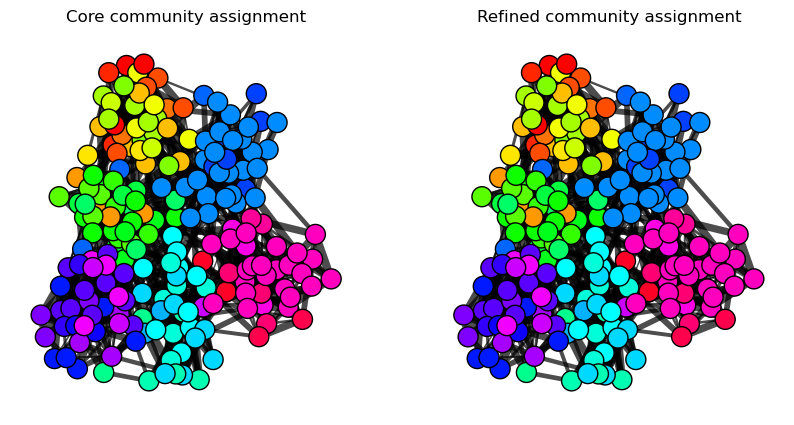

In [8]:
layout = g_test.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=initial_partition, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=refined_partition, skipLayout=True), target=ax[1])
ax[0].set_title("Core community assignment")
ax[1].set_title("Refined community assignment")
plt.show()

In [9]:
def search_community_partition(g:ig.Graph, max_iter=100, verbose=False):

    N = g.vcount() # number of nodes in graph
    if verbose:
        print(f"\n---  Starting community partition search------------------------------")
        print(f"    Current Graph: {N} nodes, {g.ecount()} edges")
        print(f"    Starting from description length L = {inf.compute_description_length(g, range(N))} bits (with trivial parititon)")

    comms_initial = core_search_algorithm(g, verbose=verbose) # runs core optimization

    if verbose:
        L_initial = inf.compute_description_length(g, comms_initial)
        print(f"Initial partition found by core search algorithm has description length L = {L_initial:.6f} bits")
        print(f"--- Starting refinement process...\n")

    # start with a loop that repeats as long as we still have improvements:
    comms_level = comms_initial
    for i in range(max_iter):
        if verbose:
            print(f"\n--- Refinement: Starting Iteration {i+1}")
        L_before = inf.compute_description_length(g, comms_level)
        # submodule refinement
        comms_level = submodule_movement_optimization(g, comms_level, recursion=True,verbose=verbose)
        # single-node refinements
        comms_level = inf.node_movement_optimization(g, comms_level, verbose=verbose)
        L_after = inf.compute_description_length(g, comms_level)
        if verbose:
            print(f"--- Refinement: Finished Iteration {i+1}")
            print(f"        L_before={L_before:.6f}, L_after={L_after:.6f}")
            print(f"        Current number of communities: {len(np.unique(comms_level))}")
        if (L_after >= L_before):
            break
        
    if i >= max_iter-1:
        warnings.warn(f"Reached maximum number of iterations ({max_iter}), stopping refinement process.")


    comms_unique = np.unique(comms_level) # get sorted list of unique communities
    n_communities = len(comms_unique) # number of unique communities

    if verbose:
        L_final = inf.compute_description_length(g, comms_level.tolist())
        print(f"\nFinal: {n_communities} communities, "
              f"L = {L_final:.6f} bits")

    return comms_level.tolist()

In [10]:
comms = search_community_partition(g_test, verbose=True)


---  Starting community partition search------------------------------
    Current Graph: 200 nodes, 941 edges
    Starting from description length L = 9.555650195033504 bits (with trivial parititon)

--- Level 0 ------------------------------
    Current Graph: 200 nodes, 941 edges
Starting from description length: 9.555650195033504
Current best description length: 7.752964736097425
Number of nodes that have been moved this iteration: 146
Continuing optimization.
Current best description length: 7.420169137087548
Number of nodes that have been moved this iteration: 40
Continuing optimization.
Current best description length: 7.286558644098275
Number of nodes that have been moved this iteration: 21
Continuing optimization.
Current best description length: 7.141300263997249
Number of nodes that have been moved this iteration: 24
Continuing optimization.
Current best description length: 6.972833691967782
Number of nodes that have been moved this iteration: 20
Continuing optimization.
Cu

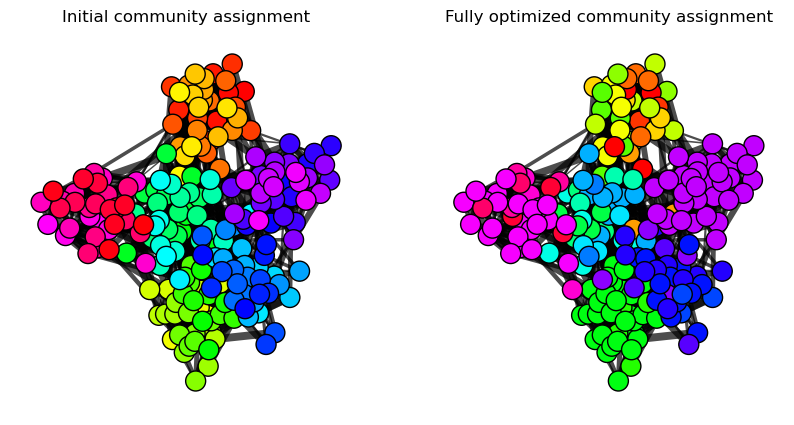

In [11]:
layout = g_test.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=range(g_test.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

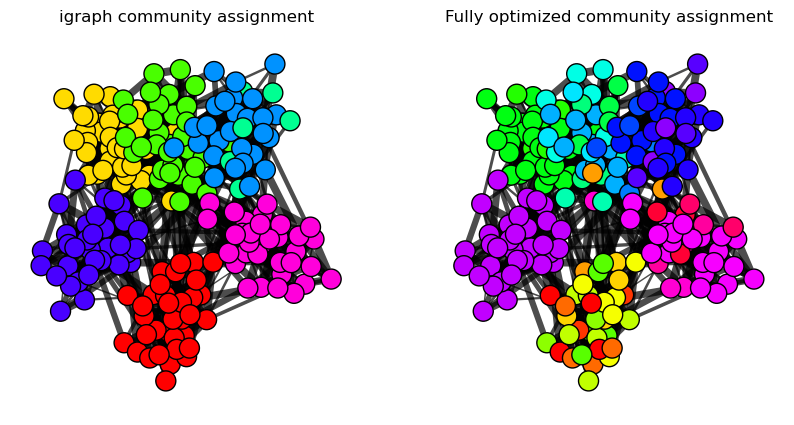

In [12]:
layout = g_test.layout('fr')
comms_ig = g_test.community_infomap(edge_weights=g_test.es['weight'], vertex_weights=None, trials=10)
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms_ig.membership, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("igraph community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

In [13]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

def compare_partitions(comms1, comms2):
    if len(comms1) != len(comms2):
        raise ValueError(f"Partition shape mismatch: comms1 and comms2 have different lengths ({len(comms1)} and {len(comms2)}).")

    nmi = normalized_mutual_info_score(comms1, comms2)
    ari = adjusted_rand_score(comms1, comms2)

    print(f"Normalized Mututal Information: {nmi:.4f}") # that one we know, between 0 and 1, if 1 -> identical partition
    # Rand score: label agreements/(label agreements + label disagreements), again, between 0 and 1, 1 -> identical partition
    # Adjusted rand score: "Adjusted for change": (RI - Expected_RI) / (max(RI) - Expected_RI)
    print(f"Adjusted Rand Index: {ari:.4f}")  # between -0.5 and 1.0, 0 -> random, 1.0 -> identical

    #return nmi, jaccard, ari

In [14]:
compare_partitions(comms, comms_ig.membership)

Normalized Mututal Information: 0.7611
Adjusted Rand Index: 0.6028
